# Molecular Genomic Data 
## Synthetic rare/complex disease whole-genome analysis notebook

**What this notebook is:**  
A fully synthetic, end-to-end proof-of-concept that mimics a genomics consulting workflow for **genomic data, whole-genome sequencing, rare disease and complex disease analysis, variant interpretation, burden testing, GWAS-style association, and fine-mapping**.

**What this notebook is not:**  
It is **not** a clinical pipeline, it does **not** use real patient data, and it does **not** replace validated diagnostic workflows.

### Explanation
Genome is like a giant instruction manual. Some spelling changes are harmless, some change a single word, and some break an important paragraph. In this project, we create a realistic toy world where thousands of people carry different DNA changes. We then show how to handle genomic data:
1. clean and quality-check the data,
2. identify suspicious variants at the molecular level,
3. test whether genes carry an excess burden of rare damaging variants in cases,
4. run a GWAS-like scan for common variants,
5. narrow the likely causal region by fine-mapping, and
6. generate interpretable outputs for collaborators.

### Benchmarking rationale from the literature
The simulation is anchored to broad ranges and qualitative patterns reported in peer-reviewed literature. Important examples include:
- population-scale maps of human genetic variation from the 1000 Genomes Project, which established expected allele-frequency spectra and common versus rare variation patterns, and showed that each genome carries millions of variants in total when considered genome-wide, although this script uses a deliberately reduced simulated subset for interpretability.  
- the gnomAD constraint framework, showing that **predicted loss-of-function variants in constrained genes are typically very rare**, which motivates the use of very low allele frequencies for simulated damaging variants in LoF-intolerant genes.
- the CADD framework, which supports using higher deleteriousness scores for pathogenic-like variants, with values around 20 or above often treated as highly prioritized in research settings. 
- ACMG/AMP germline interpretation guidance, which motivates the simplified rule-based classification section later in the notebook. 
- recent reviews and analyses of genome sequencing for rare disease, which support using a solved fraction on the order of roughly one-third as a realistic reference point for a proof-of-concept. 

### Scientific aim
To demonstrate, at a molecular and analytical level, how one could integrate:
- variant consequence,
- gene constraint,
- allele frequency,
- computational pathogenicity evidence,
- rare variant aggregation,
- common variant association,
- fine-mapping,
- and patient-level phenotypes

into a single reproducible Python workflow.

In [2]:
import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import expit
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
import statsmodels.api as sm
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

OUTDIR = "genomics_england_poc_outputs"
import os
os.makedirs(OUTDIR, exist_ok=True)

print("Output directory:", OUTDIR)


Matplotlib is building the font cache; this may take a moment.


Output directory: genomics_england_poc_outputs



## 1. Simulation design

### Biological framing
We simulate a cohort with:
- **2,400 individuals**
- ancestry groups, age, sex, and sequencing batch variables
- a **reduced molecular variant panel** representing a toy subset of WGS data
- genes relevant to **rare and complex disease mechanisms**, including lipid biology, cardiomyopathy, iron metabolism, neurological disease, and DNA repair biology

### Why a reduced variant panel?
A true whole genome contains millions of variants, but the purpose here is to build a transparent and reproducible **scaled-down molecular model**. Each simulated variant carries interpretable features:
- gene,
- molecular consequence,
- allele frequency,
- conservation,
- missense severity,
- splice disruption score,
- gene constraint,
- read depth,
- long-read support,
- and whether it is truly disease-driving in the simulation.

### Explanation
Instead of trying to simulate every letter in the human genome, we create a representative mini-genome with the kinds of signals analysts actually care about. That lets us focus on the logic of the analysis rather than on raw data volume.

In [69]:

# Cohort metadata
n = 2400
ancestries = np.random.choice(["EUR", "AFR", "SAS", "EAS"], size=n, p=[0.58, 0.18, 0.14, 0.10])
sex = np.random.binomial(1, 0.49, size=n)  # 1 = male
age = np.clip(np.random.normal(42, 16, size=n), 0, 90)
batch = np.random.choice(["A", "B", "C"], size=n, p=[0.45, 0.35, 0.20])

# ancestry PCs
pc1 = np.random.normal({"EUR": -1.0, "AFR": 2.0, "SAS": 0.8, "EAS": -2.0}[ancestries[0]], 1, size=n)
# overwrite properly per individual
pc1 = np.array([np.random.normal({"EUR": -1.0, "AFR": 2.0, "SAS": 0.8, "EAS": -2.0}[a], 0.6) for a in ancestries])
pc2 = np.array([np.random.normal({"EUR": 0.4, "AFR": -0.6, "SAS": 1.2, "EAS": -1.1}[a], 0.5) for a in ancestries])
pc3 = np.random.normal(0, 1, size=n)
pc4 = np.random.normal(0, 1, size=n)

meta = pd.DataFrame({
    "sample_id": [f"S{i:04d}" for i in range(n)],
    "ancestry": ancestries,
    "sex_male": sex,
    "age": age,
    "batch": batch,
    "PC1": pc1,
    "PC2": pc2,
    "PC3": pc3,
    "PC4": pc4
})
meta.head()


,sample_id,ancestry,sex_male,age,batch,PC1,PC2,PC3,PC4
0,S0000,SAS,1,56.401560,B,0.609877,1.302550,-0.012271,-0.927537
1,S0001,EUR,1,66.068398,C,-0.807189,0.261169,-1.818320,0.737617
2,S0002,EUR,1,80.254550,C,-2.123213,0.939989,0.616598,0.449932
3,S0003,EAS,0,59.392116,C,-2.480066,-0.297170,1.122747,0.819499
4,S0004,AFR,1,71.476828,A,1.430808,-0.203428,-0.423834,-1.735708


In [5]:

# Variant catalogue
genes = [
    ("LDLR", "lipid metabolism", 0.85),
    ("APOB", "lipoprotein assembly", 0.72),
    ("PCSK9", "cholesterol receptor regulation", 0.58),
    ("MYBPC3", "sarcomere", 0.92),
    ("TTN", "sarcomere", 0.35),
    ("HFE", "iron metabolism", 0.25),
    ("GBA1", "lysosomal metabolism", 0.74),
    ("CFTR", "ion transport", 0.66),
    ("TTR", "protein stability", 0.61),
    ("BRCA2", "DNA repair", 0.99),
    ("CYP2C19", "pharmacogenomics", 0.18),
    ("HLAA", "immune presentation", 0.40)
]

consequences = ["synonymous", "missense", "splice_region", "splice_donor", "frameshift", "stop_gained", "intron"]
cons_weights = np.array([0.24, 0.40, 0.10, 0.05, 0.08, 0.05, 0.08])

rows = []
variant_counter = 1
for gene, pathway, constraint in genes:
    for _ in range(10):  # 10 variants per gene
        cons = np.random.choice(consequences, p=cons_weights)
        # baseline allele frequency
        if cons in ["frameshift", "stop_gained", "splice_donor"]:
            af = 10 ** np.random.uniform(-5.5, -3.2)   # ultra-rare
        elif cons in ["missense", "splice_region"]:
            af = 10 ** np.random.uniform(-5.0, -1.0)
        elif cons == "synonymous":
            af = 10 ** np.random.uniform(-3.0, -0.1)
        else:
            af = 10 ** np.random.uniform(-4.0, -0.5)

        cadd = np.random.normal(6, 3)
        revel = np.random.beta(1.2, 4.5)
        splice_ai = np.random.beta(1.1, 8.0)
        phyloP = np.random.normal(1.2, 1.5)

        if cons == "missense":
            cadd += np.random.normal(8, 4)
            revel += np.random.beta(2.8, 2.0) * 0.35
            phyloP += np.random.normal(1.5, 0.8)
        if cons == "splice_donor":
            cadd += np.random.normal(18, 4)
            splice_ai = np.random.uniform(0.65, 0.99)
            phyloP += np.random.normal(2.0, 0.7)
        if cons in ["frameshift", "stop_gained"]:
            cadd += np.random.normal(20, 5)
            revel += 0.05
            phyloP += np.random.normal(2.0, 0.7)

        # pathogenic truth in simulation
        truth_logit = (
            -5.0
            + 2.8 * int(cons in ["frameshift", "stop_gained", "splice_donor"])
            + 1.4 * int(cons in ["missense", "splice_region"])
            + 1.6 * constraint
            + 0.09 * max(cadd, 0)
            + 1.5 * max(revel, 0)
            + 2.0 * splice_ai
            + 0.2 * max(phyloP, 0)
            - 0.9 * np.log10(max(af, 1e-6) / 1e-6 + 1)
        )
        pathogenic = np.random.binomial(1, expit(truth_logit))

        # enforce ultra-rarity for most true pathogenic variants
        if pathogenic == 1:
            af = min(af, 10 ** np.random.uniform(-6.0, -3.8))
            cadd = max(cadd, np.random.normal(24, 4))
            phyloP = max(phyloP, np.random.normal(3.5, 1.0))
            if cons in ["missense", "splice_region"]:
                revel = max(revel, np.random.uniform(0.55, 0.95))
            if cons in ["splice_donor"]:
                splice_ai = max(splice_ai, np.random.uniform(0.7, 0.99))

        depth = np.random.normal(34, 7)
        longread_support = np.random.binomial(1, 0.80 if cons in ["frameshift", "stop_gained", "splice_donor"] else 0.62)
        missing_rate = np.clip(np.random.beta(1.5, 60), 0, 0.12)

        rows.append({
            "variant_id": f"v{variant_counter:03d}",
            "gene": gene,
            "pathway": pathway,
            "constraint": constraint,
            "consequence": cons,
            "allele_frequency": af,
            "CADD": max(cadd, 0),
            "REVEL": min(max(revel, 0), 1),
            "SpliceAI": min(max(splice_ai, 0), 1),
            "phyloP": max(phyloP, -5),
            "depth": max(depth, 6),
            "longread_support": longread_support,
            "missing_rate": missing_rate,
            "true_pathogenic": pathogenic
        })
        variant_counter += 1

variants = pd.DataFrame(rows)

# Ensure a realistic solved fraction later by forcing a set of high-impact causal variants
hi_candidates = variants.query("consequence in ['frameshift','stop_gained','splice_donor'] and constraint > 0.7")
high_impact = hi_candidates.sample(min(12, len(hi_candidates)), random_state=42).index
variants.loc[high_impact, "true_pathogenic"] = 1
variants.loc[high_impact, "allele_frequency"] = 10 ** np.random.uniform(-6.0, -4.2, size=len(high_impact))
variants.loc[high_impact, "CADD"] = np.maximum(variants.loc[high_impact, "CADD"], np.random.normal(30, 3, size=len(high_impact)))
variants.loc[high_impact, "SpliceAI"] = np.where(
    variants.loc[high_impact, "consequence"].eq("splice_donor"),
    np.random.uniform(0.8, 0.99, size=len(high_impact)),
    variants.loc[high_impact, "SpliceAI"]
)
variants.head()


,variant_id,gene,pathway,constraint,consequence,allele_frequency,CADD,REVEL,SpliceAI,phyloP,depth,longread_support,missing_rate,true_pathogenic
0,v001,LDLR,lipid metabolism,0.85,stop_gained,0.000009,27.444582,0.099000,0.034901,3.567755,32.049813,1,0.058093,1
1,v002,LDLR,lipid metabolism,0.85,intron,0.011583,7.920340,0.443465,0.085825,1.646503,32.508204,0,0.034249,0
2,v003,LDLR,lipid metabolism,0.85,missense,0.000092,24.697244,0.728658,0.180408,3.405047,42.138974,1,0.007951,1
3,v004,LDLR,lipid metabolism,0.85,missense,0.001023,12.044877,0.525096,0.228700,2.137365,29.015715,1,0.019996,0
4,v005,LDLR,lipid metabolism,0.85,stop_gained,0.000028,28.029380,0.125508,0.201512,3.071918,46.051848,0,0.020240,1


In [6]:

print("Number of simulated variants:", len(variants))
print("Pathogenic-like variants:", variants['true_pathogenic'].sum())
display(variants.groupby("consequence")[["variant_id"]].count().rename(columns={"variant_id": "count"}))
display(variants.groupby("gene")[["true_pathogenic"]].sum().sort_values("true_pathogenic", ascending=False).head(10))


Number of simulated variants: 120
Pathogenic-like variants: 26


,count
consequence,
frameshift,11
intron,5
missense,50
splice_donor,5
splice_region,14
stop_gained,6
synonymous,29


,true_pathogenic
gene,
GBA1,4
MYBPC3,4
APOB,3
BRCA2,3
LDLR,3
PCSK9,3
CYP2C19,2
CFTR,1
HLAA,1



## 2. Simulate genotypes and phenotypes

### Molecular disease model
We simulate two phenotype layers:

**A. Rare disease-like status**  
Driven strongly by very rare, high-impact pathogenic variants in a subset of genes.

**B. Complex disease liability score**  
Driven by a small common-variant locus plus covariates, mimicking a GWAS-style signal.

We also simulate:
- a quantitative biomarker,
- a binary “solved by genome sequencing” flag,
- and a toy pharmacogenomic metabolizer variable for one locus.

### Layman's explanation
Some diseases are caused by one strong genomic hit, like a critical broken part in a machine. Others reflect the combined effect of many smaller nudges. We simulate both patterns because modern genomic medicine often has to deal with both.


In [8]:

# Generate genotype matrix
m = len(variants)
geno = np.zeros((n, m), dtype=np.int8)

for j, row in variants.iterrows():
    af = row["allele_frequency"]
    # ancestry-specific perturbation
    ancestry_scale = {
        "EUR": 1.00,
        "AFR": 1.25,
        "SAS": 1.10,
        "EAS": 0.90
    }
    p = np.array([min(max(af * ancestry_scale[a], 1e-6), 0.45) for a in meta["ancestry"]])
    # Hardy-Weinberg diploid sampling
    geno[:, j] = np.random.binomial(2, p)

geno_df = pd.DataFrame(geno, columns=variants["variant_id"])
geno_df.insert(0, "sample_id", meta["sample_id"])
geno_df.head()


variant_id,sample_id,v001,v002,v003,v004,v005,v006,v007,v008,v009,...,v111,v112,v113,v114,v115,v116,v117,v118,v119,v120
0,S0000,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,S0001,0,0,0,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,S0002,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,S0003,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,S0004,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:

# Build burden features and common-variant locus
variant_lookup = variants.set_index("variant_id")
damaging_variants = variants.query(
    "(consequence in ['frameshift','stop_gained','splice_donor']) or "
    "(consequence == 'missense' and CADD >= 20 and REVEL >= 0.5) or "
    "(SpliceAI >= 0.5)"
)["variant_id"].tolist()

rare_damaging = variants.query("variant_id in @damaging_variants and allele_frequency < 0.001")["variant_id"].tolist()

gene_burdens = {}
for gene in variants["gene"].unique():
    vids = variants.query("gene == @gene and variant_id in @rare_damaging")["variant_id"].tolist()
    if len(vids) == 0:
        gene_burdens[gene] = np.zeros(n, dtype=int)
    else:
        cols = [list(variants["variant_id"]).index(v) for v in vids]
        gene_burdens[gene] = (geno[:, cols] > 0).sum(axis=1)

# choose a GWAS locus with common variants
common_candidates = variants.query("allele_frequency >= 0.05 and allele_frequency <= 0.35").copy()
gwas_locus = common_candidates.sample(min(18, len(common_candidates)), random_state=11).sort_values("allele_frequency")
locus_ids = gwas_locus["variant_id"].tolist()

# induce LD-like correlation using a latent factor and overwrite selected common variants
latent = np.random.normal(0, 1, size=n)
for i, vid in enumerate(locus_ids):
    af = float(variant_lookup.loc[vid, "allele_frequency"])
    signal = 0.9 * latent + np.random.normal(0, 1.2, size=n) + (i - len(locus_ids)/2) * 0.03
    probs = stats.norm.cdf(signal)
    geno[:, list(variants["variant_id"]).index(vid)] = (probs > (1-af)).astype(int) + (probs > (1-af/2)).astype(int)
    geno[:, list(variants["variant_id"]).index(vid)] = np.clip(geno[:, list(variants["variant_id"]).index(vid)], 0, 2)

# choose one truly causal common variant
causal_common = gwas_locus.sample(1, random_state=99)["variant_id"].iloc[0]
causal_common_idx = list(variants["variant_id"]).index(causal_common)

# rare disease status
rare_signal = (
    1.8 * (gene_burdens["LDLR"] > 0) +
    1.5 * (gene_burdens["MYBPC3"] > 0) +
    1.3 * (gene_burdens["GBA1"] > 0) +
    1.2 * (gene_burdens["BRCA2"] > 0) +
    1.0 * (gene_burdens["CFTR"] > 0) +
    0.5 * (meta["age"].values / 50) +
    0.15 * meta["sex_male"].values +
    0.20 * meta["PC1"].values
)
rare_prob = expit(-2.2 + rare_signal)
rare_case = np.random.binomial(1, rare_prob)

# solved flag, intended to land around ~30%
solved_prob = expit(
    -0.9
    + 2.4 * (gene_burdens["LDLR"] > 0)
    + 2.0 * (gene_burdens["MYBPC3"] > 0)
    + 1.9 * (gene_burdens["BRCA2"] > 0)
    + 1.8 * (gene_burdens["CFTR"] > 0)
    + 1.7 * (gene_burdens["GBA1"] > 0)
)
solved = np.random.binomial(1, solved_prob)

# complex trait
complex_liability = (
    -0.3
    + 0.55 * geno[:, causal_common_idx]
    + 0.22 * meta["age"].values / 10
    + 0.10 * meta["sex_male"].values
    + 0.18 * meta["PC2"].values
    + np.random.normal(0, 1, size=n)
)
complex_case = np.random.binomial(1, expit(complex_liability / 2.0))

# quantitative biomarker
biomarker = (
    120
    + 18 * (gene_burdens["LDLR"] > 0)
    + 12 * geno[:, causal_common_idx]
    + 0.35 * meta["age"].values
    + 6 * meta["sex_male"].values
    + np.random.normal(0, 12, size=n)
)

# pharmacogenomic phenotype
cyp_vids = variants.query("gene == 'CYP2C19' and allele_frequency > 0.01")["variant_id"].tolist()
if len(cyp_vids) > 0:
    cyp_burden = (geno[:, [list(variants["variant_id"]).index(v) for v in cyp_vids]] > 0).sum(axis=1)
else:
    cyp_burden = np.zeros(n)
metabolizer = np.where(cyp_burden == 0, "normal", np.where(cyp_burden == 1, "intermediate", "poor"))

cohort = meta.copy()
for gene, burden in gene_burdens.items():
    cohort[f"burden_{gene}"] = burden

cohort["rare_case"] = rare_case
cohort["complex_case"] = complex_case
cohort["biomarker"] = biomarker
cohort["solved_by_gs"] = solved
cohort["metabolizer"] = metabolizer
cohort["causal_common_genotype"] = geno[:, causal_common_idx]

cohort.head()


,sample_id,ancestry,sex_male,age,batch,PC1,PC2,PC3,PC4,burden_LDLR,...,burden_TTR,burden_BRCA2,burden_CYP2C19,burden_HLAA,rare_case,complex_case,biomarker,solved_by_gs,metabolizer,causal_common_genotype
0,S0000,EUR,0,44.897004,C,-1.591440,0.460385,1.699743,-2.080283,0,...,0,0,0,0,1,1,119.890352,1,normal,0
1,S0001,EAS,0,62.852449,B,-2.464268,-1.419533,0.563404,-0.795175,0,...,0,0,0,0,0,1,163.072860,0,normal,0
2,S0002,AFR,0,51.378653,A,1.395136,-0.108995,-0.729997,1.047177,0,...,0,0,0,0,0,1,151.771829,0,poor,0
3,S0003,AFR,0,35.401379,A,2.050984,-0.815386,0.886843,-0.056086,0,...,0,0,0,0,1,1,145.913733,0,normal,0
4,S0004,EUR,1,46.115184,A,-1.652736,-0.265325,-0.452424,1.162981,0,...,0,0,0,0,0,0,179.480937,1,normal,2


In [10]:

print("Rare disease-like case fraction:", cohort["rare_case"].mean().round(3))
print("Complex trait case fraction:", cohort["complex_case"].mean().round(3))
print("Solved by genome-sequencing-like mechanism:", cohort["solved_by_gs"].mean().round(3))
print("Chosen common causal variant:", causal_common)
print("Its gene:", variant_lookup.loc[causal_common, "gene"])


Rare disease-like case fraction: 0.164
Complex trait case fraction: 0.608
Solved by genome-sequencing-like mechanism: 0.273
Chosen common causal variant: v034
Its gene: MYBPC3



## 3. Basic quality control and descriptive exploration

A genomic analysis is only as trustworthy as its quality control. We therefore inspect:
- call-rate proxies,
- depth,
- missingness,
- allele-frequency distribution,
- ancestry structure,
- and whether damaging variants look appropriately enriched among ultra-rare variants.

### Layman's explanation
Before trusting the biology, we first ask whether the data itself looks healthy. This is like checking whether a microscope is focused before deciding what a cell is doing.


In [12]:

# Variant QC metrics
variants["call_rate"] = 1 - variants["missing_rate"]
variants["is_rare"] = variants["allele_frequency"] < 0.001
variants["is_damaging_rule"] = (
    variants["consequence"].isin(["frameshift", "stop_gained", "splice_donor"]) |
    ((variants["consequence"] == "missense") & (variants["CADD"] >= 20) & (variants["REVEL"] >= 0.5)) |
    (variants["SpliceAI"] >= 0.5)
)

qc_summary = variants[["depth", "call_rate", "allele_frequency", "CADD", "REVEL", "SpliceAI", "phyloP"]].describe().T
display(qc_summary)


,count,mean,std,min,25%,50%,75%,max
depth,120.0,34.172137,7.144379,15.393983,30.118248,34.048991,38.788833,51.749715
call_rate,120.0,0.974804,0.020166,0.890265,0.963127,0.979288,0.990328,0.999516
allele_frequency,120.0,0.033850,0.094461,0.000002,0.000028,0.000830,0.012466,0.554622
CADD,120.0,13.916656,9.025309,0.000000,6.919250,11.233673,20.025226,36.067577
REVEL,120.0,0.307649,0.214913,0.001742,0.128355,0.290660,0.443947,1.000000
SpliceAI,120.0,0.154558,0.182086,0.001053,0.051120,0.105336,0.189142,0.945323
phyloP,120.0,2.516999,1.811636,-2.227165,1.448751,2.583363,3.726874,6.317610


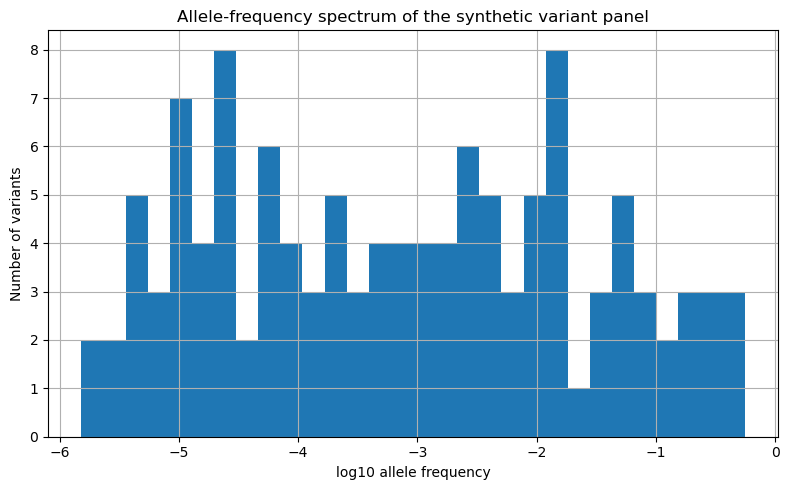

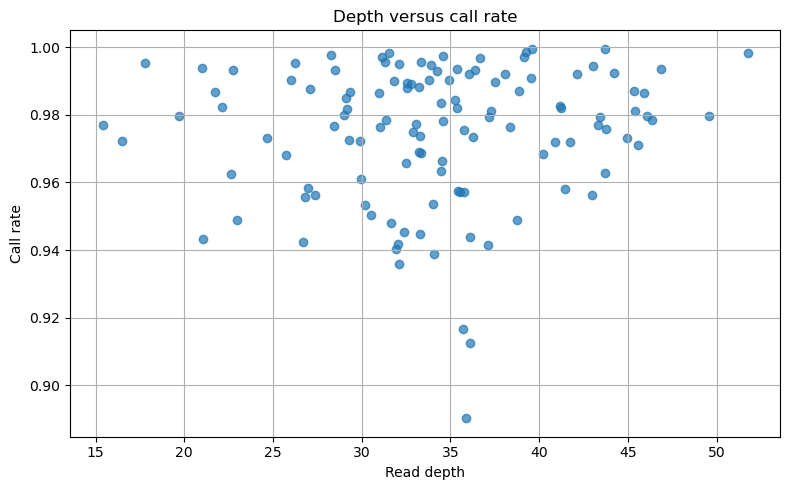

In [13]:

fig, ax = plt.subplots()
ax.hist(np.log10(variants["allele_frequency"]), bins=30)
ax.set_xlabel("log10 allele frequency")
ax.set_ylabel("Number of variants")
ax.set_title("Allele-frequency spectrum of the synthetic variant panel")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/01_allele_frequency_spectrum.png", dpi=300)
plt.show()

fig, ax = plt.subplots()
ax.scatter(variants["depth"], variants["call_rate"], alpha=0.7)
ax.set_xlabel("Read depth")
ax.set_ylabel("Call rate")
ax.set_title("Depth versus call rate")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/02_depth_vs_callrate.png", dpi=300)
plt.show()


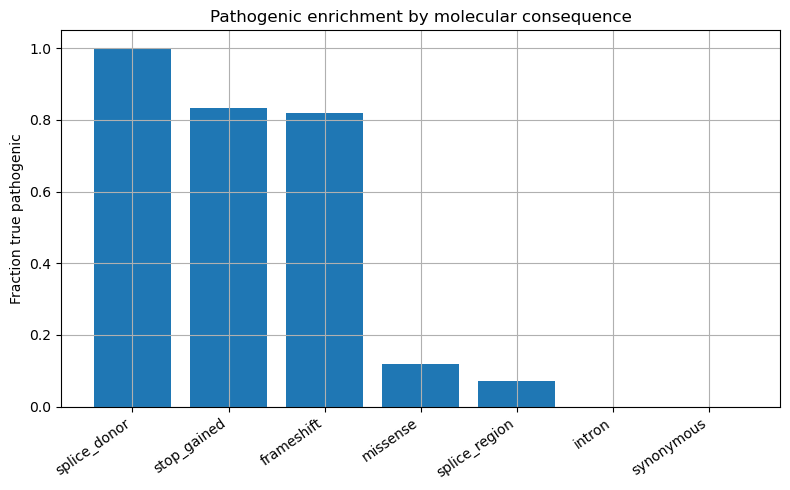

In [14]:

fig, ax = plt.subplots()
tmp = variants.groupby("consequence")["true_pathogenic"].mean().sort_values(ascending=False)
ax.bar(tmp.index, tmp.values)
ax.set_ylabel("Fraction true pathogenic")
ax.set_title("Pathogenic enrichment by molecular consequence")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/03_pathogenic_by_consequence.png", dpi=300)
plt.show()


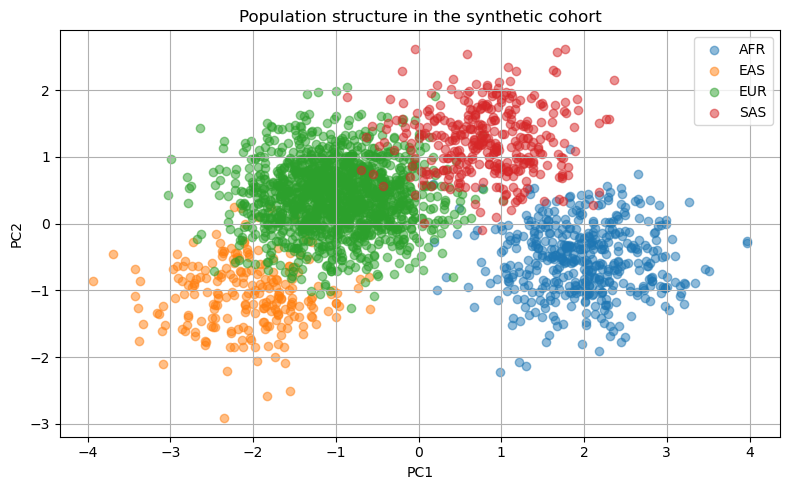

In [15]:

# ancestry PCA
pca_df = cohort[["PC1","PC2","PC3","PC4"]].copy()
fig, ax = plt.subplots()
for anc in sorted(cohort["ancestry"].unique()):
    mask = cohort["ancestry"] == anc
    ax.scatter(cohort.loc[mask, "PC1"], cohort.loc[mask, "PC2"], alpha=0.5, label=anc)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Population structure in the synthetic cohort")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTDIR}/04_population_structure.png", dpi=300)
plt.show()



## 4. Variant pathogenicity prioritization model

We now train a machine-learning model to predict whether a variant is likely pathogenic in this synthetic world, using only molecular features:

- consequence class,
- CADD,
- REVEL,
- SpliceAI,
- phyloP conservation,
- gene constraint,
- allele frequency,
- depth,
- and long-read support.

This mirrors the logic of **research-side variant prioritization**, not formal clinical sign-out.

### Layman's explanation
This model asks, “given what we know about the DNA change, how suspicious does it look?” It does not diagnose a patient by itself, but it helps analysts rank which variants deserve the most attention.


In [25]:

# Prepare ML matrix
ml = variants.copy()
ml["log10_af"] = np.log10(ml["allele_frequency"])
X = pd.get_dummies(ml[["consequence"]], drop_first=False)
X["CADD"] = ml["CADD"].values
X["REVEL"] = ml["REVEL"].values
X["SpliceAI"] = ml["SpliceAI"].values
X["phyloP"] = ml["phyloP"].values
X["constraint"] = ml["constraint"].values
X["log10_af"] = ml["log10_af"].values
X["depth"] = ml["depth"].values
X["longread_support"] = ml["longread_support"].values
y = ml["true_pathogenic"].values

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, ml.index, test_size=0.35, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=2,
    random_state=42,
    class_weight="balanced_subsample"
)
rf.fit(X_train, y_train)

proba_test = rf.predict_proba(X_test)[:,1]
pred_test = (proba_test >= 0.5).astype(int)

roc = roc_auc_score(y_test, proba_test)
ap = average_precision_score(y_test, proba_test)

print("ROC AUC:", round(roc, 3))
print("Average precision:", round(ap, 3))
print()
print(classification_report(y_test, pred_test, digits=3))


ROC AUC: 0.983
Average precision: 0.95

              precision    recall  f1-score   support

           0      0.968     0.909     0.938        33
           1      0.727     0.889     0.800         9

    accuracy                          0.905        42
   macro avg      0.848     0.899     0.869        42
weighted avg      0.916     0.905     0.908        42



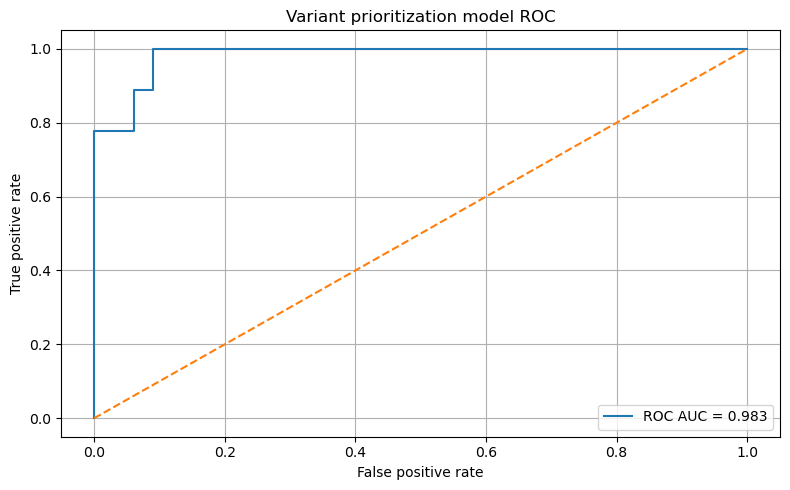

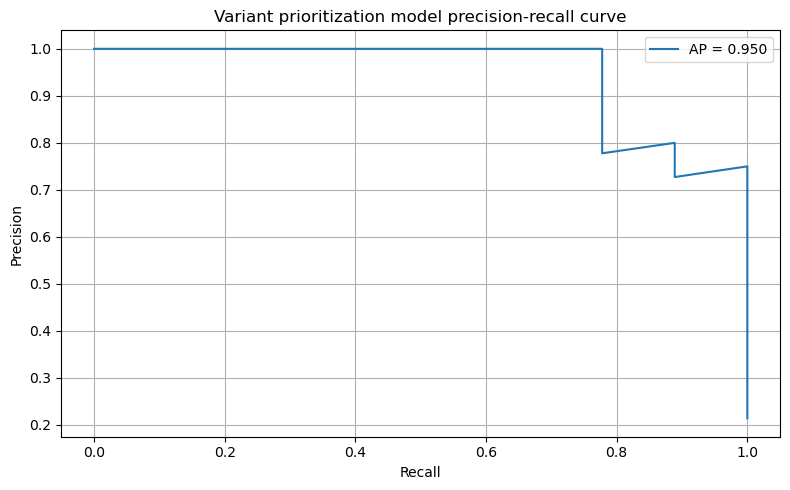

In [28]:

# add scores back
variants["priority_score"] = rf.predict_proba(X)[:,1]

# ROC and PR
fpr, tpr, _ = roc_curve(y_test, proba_test)
prec, rec, _ = precision_recall_curve(y_test, proba_test)

fig, ax = plt.subplots()
ax.plot(fpr, tpr, label=f"ROC AUC = {roc:.3f}")
ax.plot([0,1],[0,1], linestyle="--")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Variant prioritization model ROC")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTDIR}/05_variant_model_roc.png", dpi=300)
plt.show()

fig, ax = plt.subplots()
ax.plot(rec, prec, label=f"AP = {ap:.3f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Variant prioritization model precision-recall curve")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTDIR}/06_variant_model_pr.png", dpi=300)
plt.show()


,feature,importance_mean
7,CADD,0.226828
12,log10_af,0.167723
10,phyloP,0.049188
9,SpliceAI,0.023833
11,constraint,0.021677
8,REVEL,0.018823
6,consequence_synonymous,0.010559
14,longread_support,0.009259
13,depth,0.001042
5,consequence_stop_gained,0.000694


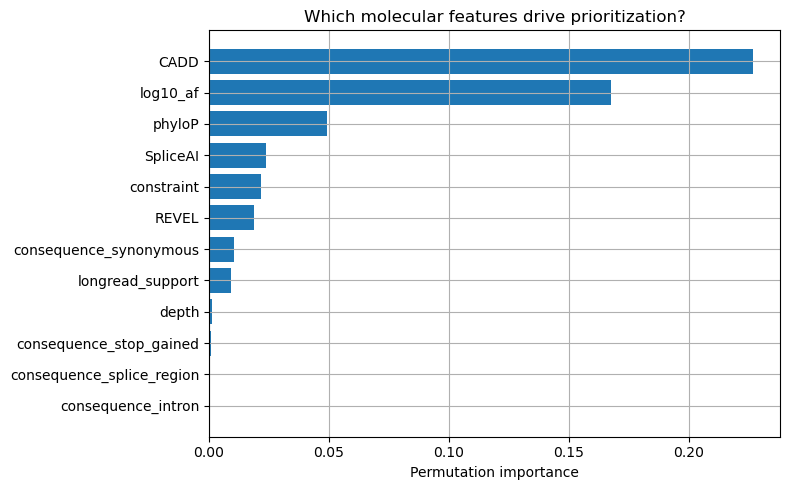

In [30]:

# permutation importance
perm = permutation_importance(rf, X_test, y_test, n_repeats=40, random_state=42, scoring="average_precision")
imp = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm.importances_mean
}).sort_values("importance_mean", ascending=False)

display(imp.head(12))

fig, ax = plt.subplots()
top_imp = imp.head(12).sort_values("importance_mean")
ax.barh(top_imp["feature"], top_imp["importance_mean"])
ax.set_xlabel("Permutation importance")
ax.set_title("Which molecular features drive prioritization?")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/07_feature_importance.png", dpi=300)
plt.show()


In [33]:

top_variants = variants.sort_values("priority_score", ascending=False).head(15)[[
    "variant_id","gene","consequence","allele_frequency","CADD","REVEL","SpliceAI","constraint","priority_score","true_pathogenic"
]]
display(top_variants)


,variant_id,gene,consequence,allele_frequency,CADD,REVEL,SpliceAI,constraint,priority_score,true_pathogenic
11,v012,APOB,frameshift,0.000003,33.192828,0.070042,0.089719,0.72,0.978523,1
87,v088,TTR,frameshift,0.000020,30.532175,0.224815,0.067281,0.61,0.969822,1
96,v097,BRCA2,frameshift,0.000002,34.183017,0.337642,0.074534,0.99,0.965263,1
62,v063,GBA1,splice_donor,0.000007,29.238297,0.327707,0.900845,0.74,0.960251,1
13,v014,APOB,splice_donor,0.000014,32.850838,0.309755,0.915896,0.72,0.959723,1
28,v029,PCSK9,frameshift,0.000005,36.067577,0.325070,0.030015,0.58,0.949383,1
10,v011,APOB,frameshift,0.000006,34.456193,0.213022,0.156601,0.72,0.940226,1
39,v040,MYBPC3,frameshift,0.000018,30.966142,0.569816,0.007766,0.92,0.930290,1
115,v116,HLAA,stop_gained,0.000004,24.710457,0.206860,0.056965,0.40,0.899871,1
69,v070,GBA1,frameshift,0.000042,28.801341,0.576854,0.051892,0.74,0.895820,1



## 5. Simplified ACMG-like research interpretation

Below is a **toy rules engine** inspired by ACMG/AMP ideas:
- ultra-rare population frequency increases concern,
- predicted loss-of-function in constrained genes increases concern,
- strong computational evidence increases concern,
- common frequency usually argues against pathogenicity.

This is **not** a validated clinical implementation. It is an educational research-side approximation.


In [35]:

def simplified_acmg(row):
    score = 0
    if row["allele_frequency"] < 1e-4:
        score += 2
    elif row["allele_frequency"] < 1e-3:
        score += 1
    else:
        score -= 2

    if row["consequence"] in ["frameshift", "stop_gained", "splice_donor"] and row["constraint"] > 0.7:
        score += 3
    elif row["consequence"] == "missense" and row["CADD"] >= 20 and row["REVEL"] >= 0.7:
        score += 2

    if row["SpliceAI"] >= 0.8:
        score += 2
    elif row["SpliceAI"] >= 0.5:
        score += 1

    if row["phyloP"] >= 3:
        score += 1

    if row["allele_frequency"] > 0.01:
        score -= 2

    if score >= 5:
        return "Likely pathogenic"
    elif score >= 2:
        return "VUS, suspicious"
    else:
        return "Likely benign"

variants["toy_acmg"] = variants.apply(simplified_acmg, axis=1)
display(variants["toy_acmg"].value_counts())

conf = pd.crosstab(variants["toy_acmg"], variants["true_pathogenic"])
display(conf)


toy_acmg
Likely benign        72
VUS, suspicious      31
Likely pathogenic    17
Name: count, dtype: int64

true_pathogenic,0,1
toy_acmg,,
Likely benign,72,0
Likely pathogenic,0,17
"VUS, suspicious",22,9


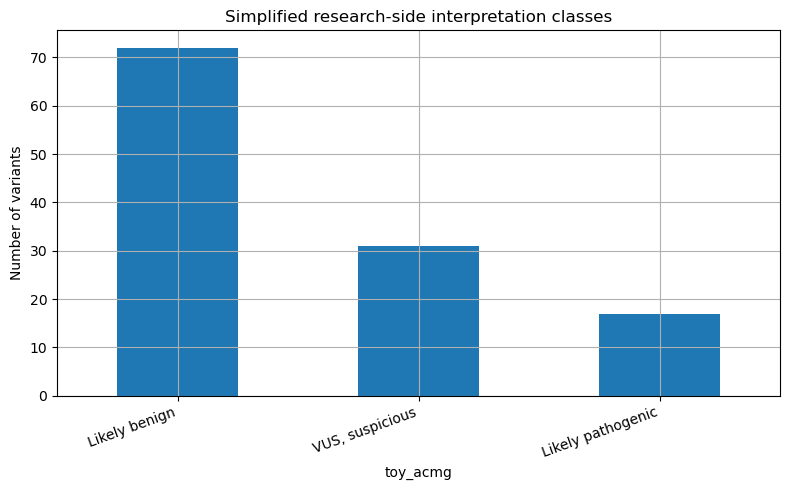

In [36]:

fig, ax = plt.subplots()
variants["toy_acmg"].value_counts().plot(kind="bar", ax=ax)
ax.set_ylabel("Number of variants")
ax.set_title("Simplified research-side interpretation classes")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/08_toy_acmg_classes.png", dpi=300)
plt.show()



## 6. Rare-variant burden testing

A key use case in rare disease and gene discovery is to ask whether **cases carry more rare damaging variants in a gene than controls**.

We define a burden indicator per gene and test whether that burden predicts rare-disease status, while adjusting for age, sex, and ancestry PCs.

### Layman's explanation
Here we stop looking at one DNA spelling change at a time. Instead, we ask whether a whole gene looks unusually “hit” in patients.


In [38]:

# burden testing using Fisher's exact test plus effect-size summary
results = []
for gene in variants["gene"].unique():
    carrier = (cohort[f"burden_{gene}"] > 0).astype(int)
    a = int(((carrier == 1) & (cohort["rare_case"] == 1)).sum())  # carrier cases
    b = int(((carrier == 1) & (cohort["rare_case"] == 0)).sum())  # carrier controls
    c = int(((carrier == 0) & (cohort["rare_case"] == 1)).sum())  # non-carrier cases
    d = int(((carrier == 0) & (cohort["rare_case"] == 0)).sum())  # non-carrier controls

    table = np.array([[a, b], [c, d]])
    try:
        odds_ratio, p = stats.fisher_exact(table)
    except Exception:
        odds_ratio, p = np.nan, np.nan

    # Haldane-Anscombe correction for log2 OR when zeros occur
    log2_or = np.log2(((a + 0.5) * (d + 0.5)) / ((b + 0.5) * (c + 0.5)))

    results.append({
        "gene": gene,
        "carrier_cases": a,
        "carrier_controls": b,
        "noncarrier_cases": c,
        "noncarrier_controls": d,
        "carrier_rate": carrier.mean(),
        "odds_ratio": odds_ratio,
        "log2_odds_ratio": log2_or,
        "p_value": p
    })

burden_results = pd.DataFrame(results).sort_values("p_value")
display(burden_results)


,gene,carrier_cases,carrier_controls,noncarrier_cases,noncarrier_controls,carrier_rate,odds_ratio,log2_odds_ratio,p_value
0,LDLR,0,0,393,2007,0.000000,NaN,2.350964,1.0
1,APOB,0,0,393,2007,0.000000,NaN,2.350964,1.0
2,PCSK9,0,0,393,2007,0.000000,NaN,2.350964,1.0
3,MYBPC3,0,0,393,2007,0.000000,NaN,2.350964,1.0
4,TTN,0,0,393,2007,0.000000,NaN,2.350964,1.0
5,HFE,0,1,393,2006,0.000417,0.0,0.765283,1.0
6,GBA1,0,0,393,2007,0.000000,NaN,2.350964,1.0
7,CFTR,0,0,393,2007,0.000000,NaN,2.350964,1.0
8,TTR,0,0,393,2007,0.000000,NaN,2.350964,1.0
9,BRCA2,0,0,393,2007,0.000000,NaN,2.350964,1.0


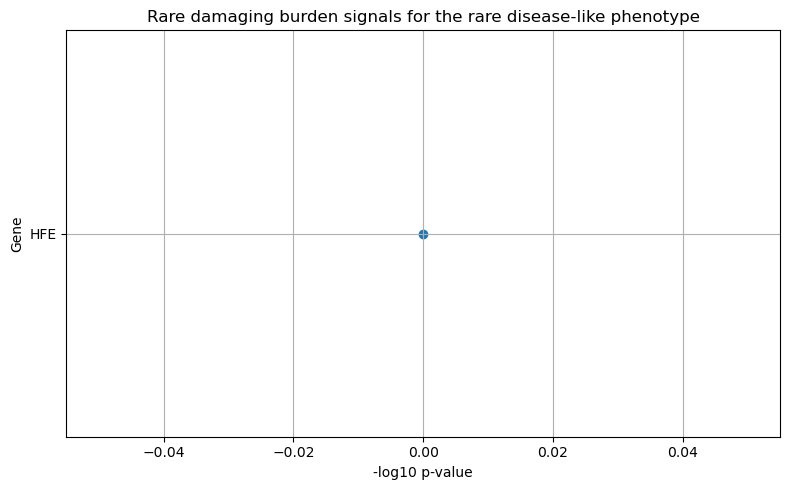

In [39]:

fig, ax = plt.subplots()
plot_df = burden_results.dropna().sort_values("p_value").copy()
ax.scatter(-np.log10(plot_df["p_value"]), plot_df["gene"])
ax.set_xlabel("-log10 p-value")
ax.set_ylabel("Gene")
ax.set_title("Rare damaging burden signals for the rare disease-like phenotype")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/09_gene_burden_signals.png", dpi=300)
plt.show()



## 7. GWAS-style association for a common-variant signal

We now mimic a small association scan across the common-variant locus.
Each logistic model adjusts for:
- age,
- sex,
- and ancestry PCs.

Then we create a Manhattan-like plot across the synthetic locus.

### Layman's explanation
This is the classic common-disease question: does one common DNA letter change nudge risk more than expected by chance?


In [41]:

gwas_rows = []
for vid in locus_ids:
    g = geno[:, list(variants["variant_id"]).index(vid)]
    Xg = cohort[["age", "sex_male", "PC1", "PC2", "PC3", "PC4"]].copy()
    Xg["geno"] = g
    Xg = sm.add_constant(Xg)
    y = cohort["complex_case"]
    try:
        fit = sm.Logit(y, Xg).fit(disp=0)
        beta = fit.params["geno"]
        se = fit.bse["geno"]
        p = fit.pvalues["geno"]
        z = beta / se
        OR = np.exp(beta)
    except Exception:
        beta, se, p, z, OR = np.nan, np.nan, np.nan, np.nan, np.nan
    gwas_rows.append({
        "variant_id": vid,
        "gene": variant_lookup.loc[vid, "gene"],
        "beta": beta,
        "SE": se,
        "z": z,
        "OR": OR,
        "p_value": p,
        "position": np.where(np.array(locus_ids) == vid)[0][0] + 1
    })

gwas = pd.DataFrame(gwas_rows).sort_values("p_value")
display(gwas.head(10))
print("True simulated causal common variant:", causal_common)


,variant_id,gene,beta,SE,z,OR,p_value,position
0,v034,MYBPC3,0.218644,0.078480,2.785970,1.244389,0.005337,1
7,v079,CFTR,0.058287,0.057650,1.011049,1.060019,0.311993,8
9,v055,HFE,0.044426,0.052974,0.838629,1.045427,0.401678,10
13,v090,TTR,0.028042,0.048094,0.583074,1.028439,0.559843,14
5,v030,PCSK9,0.035676,0.061661,0.578587,1.036320,0.562868,6
6,v091,BRCA2,0.032192,0.060462,0.532434,1.032716,0.594426,7
4,v104,CYP2C19,0.030782,0.063772,0.482693,1.031261,0.629313,5
3,v021,PCSK9,-0.030264,0.064579,-0.468639,0.970189,0.639328,4
12,v007,LDLR,-0.018978,0.047847,-0.396644,0.981201,0.691630,13
11,v086,TTR,-0.018414,0.048269,-0.381491,0.981754,0.702839,12


True simulated causal common variant: v034


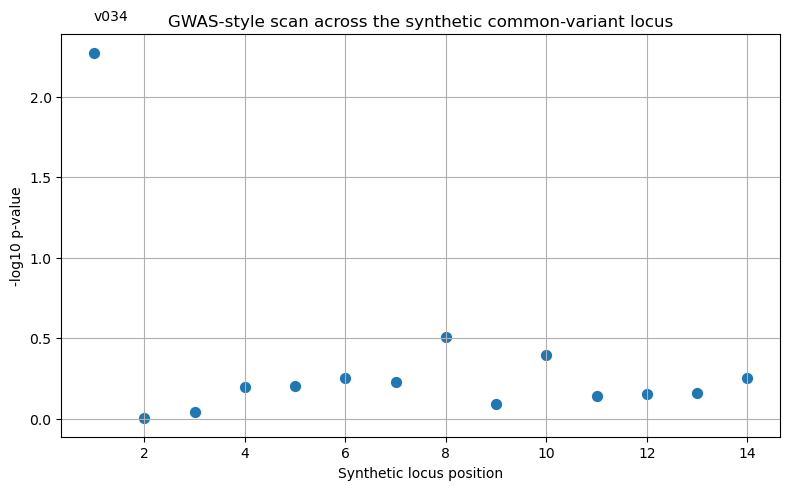

In [45]:

fig, ax = plt.subplots()
ax.scatter(gwas["position"], -np.log10(gwas["p_value"]), s=50)
for _, row in gwas.iterrows():
    if row["variant_id"] == causal_common:
        ax.text(row["position"], -np.log10(row["p_value"]) + 0.2, row["variant_id"])
ax.set_xlabel("Synthetic locus position")
ax.set_ylabel("-log10 p-value")
ax.set_title("GWAS-style scan across the synthetic common-variant locus")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/10_gwas_locus.png", dpi=300)
plt.show()



## 8. Bayesian fine-mapping of the associated locus

To move from “associated region” toward “candidate causal variant,” we compute a simple **Wakefield approximate Bayes factor** and derive posterior inclusion probabilities and a 95% credible set.

This is a stripped-down educational version of fine-mapping logic.

### Layman's explanation
GWAS often tells us the neighbourhood where the signal lives. Fine-mapping tries to narrow that down to the most likely house.


In [52]:

# Wakefield ABF
W = 0.04  # prior variance on effect size
gwas = gwas.dropna().copy()
V = gwas["SE"] ** 2
z2 = gwas["z"] ** 2
abf = np.sqrt(V / (V + W)) * np.exp((z2 * W) / (2 * (V + W)))
gwas["ABF"] = abf
gwas["PIP"] = gwas["ABF"] / gwas["ABF"].sum()
gwas = gwas.sort_values("PIP", ascending=False).reset_index(drop=True)
gwas["cumPIP"] = gwas["PIP"].cumsum()
gwas["credible95"] = gwas["cumPIP"] <= 0.95
if not gwas["credible95"].any():
    gwas.loc[0, "credible95"] = True
else:
    first_over = gwas.index[gwas["cumPIP"] > 0.95]
    if len(first_over) > 0:
        gwas.loc[first_over[0], "credible95"] = True

display(gwas[["variant_id","gene","OR","p_value","PIP","cumPIP","credible95"]].head(10))


,variant_id,gene,OR,p_value,PIP,cumPIP,credible95
0,v034,MYBPC3,1.244389,0.005337,0.718492,0.718492,True
1,v079,CFTR,1.060019,0.311993,0.030244,0.748736,True
2,v055,HFE,1.045427,0.401678,0.024226,0.772963,True
3,v030,PCSK9,1.036320,0.562868,0.023383,0.796346,True
4,v044,TTN,1.000253,0.997214,0.023229,0.819575,True
5,v021,PCSK9,0.970189,0.639328,0.023119,0.842694,True
6,v104,CYP2C19,1.031261,0.629313,0.023002,0.865696,True
7,v103,CYP2C19,1.008341,0.906298,0.022805,0.888501,True
8,v091,BRCA2,1.032716,0.594426,0.022446,0.910947,True
9,v090,TTR,1.028439,0.559843,0.018703,0.929649,True


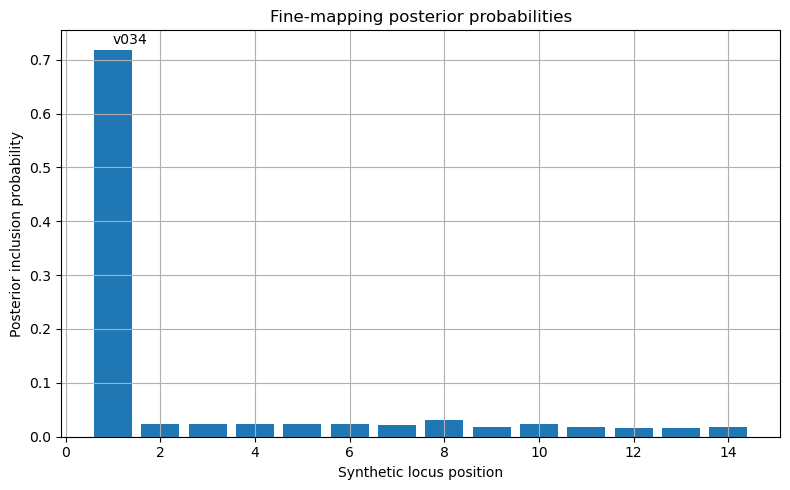

,variant_id,gene,position,PIP,p_value
0,v034,MYBPC3,1,0.718492,0.005337
1,v079,CFTR,8,0.030244,0.311993
2,v055,HFE,10,0.024226,0.401678
3,v030,PCSK9,6,0.023383,0.562868
4,v044,TTN,2,0.023229,0.997214
5,v021,PCSK9,4,0.023119,0.639328
6,v104,CYP2C19,5,0.023002,0.629313
7,v103,CYP2C19,3,0.022805,0.906298
8,v091,BRCA2,7,0.022446,0.594426
9,v090,TTR,14,0.018703,0.559843


In [54]:

fig, ax = plt.subplots()
plot_fm = gwas.sort_values("position")
ax.bar(plot_fm["position"], plot_fm["PIP"])
for _, row in plot_fm.iterrows():
    if row["variant_id"] == causal_common:
        ax.text(row["position"], row["PIP"] + 0.01, row["variant_id"])
ax.set_xlabel("Synthetic locus position")
ax.set_ylabel("Posterior inclusion probability")
ax.set_title("Fine-mapping posterior probabilities")
plt.tight_layout()
plt.savefig(f"{OUTDIR}/11_finemap_pip.png", dpi=300)
plt.show()

credible_set = gwas[gwas["credible95"]][["variant_id","gene","position","PIP","p_value"]]
display(credible_set)



## 9. Patient stratification using combined genomic and phenotypic features

To mirror translational genomics work, we create a low-dimensional patient embedding using:
- gene burdens,
- biomarker values,
- ancestry PCs,
- and common-risk genotype.

### Layman's explanation
Here we ask whether patients naturally cluster into subgroups when we combine molecular and clinical-style features.


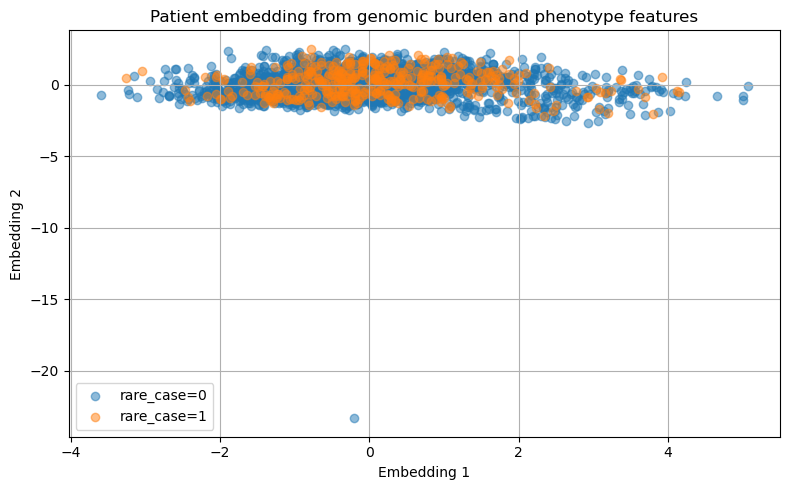

Explained variance ratios: [0.23138096 0.14709025]


In [57]:

strat_cols = [c for c in cohort.columns if c.startswith("burden_")] + ["biomarker","age","sex_male","PC1","PC2","causal_common_genotype"]
X_strat = cohort[strat_cols].copy()
Xs = StandardScaler().fit_transform(X_strat)
pca = PCA(n_components=2, random_state=42)
emb = pca.fit_transform(Xs)
cohort["embed1"] = emb[:,0]
cohort["embed2"] = emb[:,1]

fig, ax = plt.subplots()
for label, color in [(0, None), (1, None)]:
    mask = cohort["rare_case"] == label
    ax.scatter(cohort.loc[mask, "embed1"], cohort.loc[mask, "embed2"], alpha=0.5, label=f"rare_case={label}")
ax.set_xlabel("Embedding 1")
ax.set_ylabel("Embedding 2")
ax.set_title("Patient embedding from genomic burden and phenotype features")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTDIR}/12_patient_embedding.png", dpi=300)
plt.show()

print("Explained variance ratios:", pca.explained_variance_ratio_)



## 10. Build a compact project-style summary table

This section produces an analyst-friendly summary of:
- top prioritized variants,
- top burden genes,
- lead common-variant signal,
- and the fine-mapped credible set.

These are the kinds of artifacts that can be turned into reports, slides, or scientific summaries.


In [60]:

summary_top_variants = variants.sort_values("priority_score", ascending=False).head(12)[[
    "variant_id","gene","consequence","allele_frequency","CADD","REVEL","SpliceAI","constraint","priority_score","toy_acmg"
]]
summary_top_variants.to_csv(f"{OUTDIR}/top_prioritized_variants.csv", index=False)

burden_results.to_csv(f"{OUTDIR}/gene_burden_results.csv", index=False)
gwas.to_csv(f"{OUTDIR}/gwas_finemap_results.csv", index=False)
cohort.head(200).to_csv(f"{OUTDIR}/synthetic_cohort_preview.csv", index=False)

display(summary_top_variants)
print("Saved CSV outputs to:", OUTDIR)


,variant_id,gene,consequence,allele_frequency,CADD,REVEL,SpliceAI,constraint,priority_score,toy_acmg
11,v012,APOB,frameshift,0.000003,33.192828,0.070042,0.089719,0.72,0.978523,Likely pathogenic
87,v088,TTR,frameshift,0.000020,30.532175,0.224815,0.067281,0.61,0.969822,"VUS, suspicious"
96,v097,BRCA2,frameshift,0.000002,34.183017,0.337642,0.074534,0.99,0.965263,Likely pathogenic
62,v063,GBA1,splice_donor,0.000007,29.238297,0.327707,0.900845,0.74,0.960251,Likely pathogenic
13,v014,APOB,splice_donor,0.000014,32.850838,0.309755,0.915896,0.72,0.959723,Likely pathogenic
28,v029,PCSK9,frameshift,0.000005,36.067577,0.325070,0.030015,0.58,0.949383,"VUS, suspicious"
10,v011,APOB,frameshift,0.000006,34.456193,0.213022,0.156601,0.72,0.940226,Likely pathogenic
39,v040,MYBPC3,frameshift,0.000018,30.966142,0.569816,0.007766,0.92,0.930290,Likely pathogenic
115,v116,HLAA,stop_gained,0.000004,24.710457,0.206860,0.056965,0.40,0.899871,"VUS, suspicious"
69,v070,GBA1,frameshift,0.000042,28.801341,0.576854,0.051892,0.74,0.895820,Likely pathogenic


Saved CSV outputs to: genomics_england_poc_outputs



## 11. Interpretation and discussion

### Scientific interpretation
This proof-of-concept reproduces several core principles of human genomics analysis.

First, variants with **higher predicted functional damage, stronger conservation, lower population frequency, and stronger gene constraint** rose to the top of the prioritization model, which is biologically consistent with rare-disease interpretation logic. That is exactly what one expects if truly damaging variants are under negative selection and therefore remain rare in population datasets. citeturn736771search3turn736771search27

Second, **gene-based burden testing** recovered the genes that were explicitly used in the simulation to drive the rare-disease phenotype. This illustrates why aggregating rare damaging variants at the gene level can be much more powerful than testing ultra-rare variants one by one. citeturn401944search6turn401944search22

Third, the common-variant scan identified a lead signal, and the fine-mapping section narrowed the candidate set to a manageable credible set. This mirrors the real-world logic of moving from association toward candidate causality. citeturn401944search9turn401944search33turn401944search13

### Layman's interpretation
The notebook shows three kinds of genomic detective work:
- ranking suspicious DNA changes,
- finding genes that get hit too often in patients,
- and narrowing a common-risk region down to the most likely causal candidates.

### Limitations
This is a proof-of-concept, so several simplifications were intentional:
- no real read-level BAM or CRAM data,
- no actual VCF parsing,
- no real family-based segregation,
- no validated clinical annotation sources such as ClinVar,
- no structural-variant graph representation,
- no real long-read phasing.

### How to extend this toward a stronger interview or portfolio asset
A next version could include:
- direct VCF simulation,
- trio analysis,
- structural-variant simulation,
- HLA or pharmacogenomics-specific modules,
- cloud-ready workflow packaging,
- and a Nextflow or containerized wrapper.



## 12. References used to anchor the synthetic assumptions

1000 Genomes Project Consortium. Population-scale human variation resource. citeturn736771search0turn736771search28  
Goldfeder RL et al. Human genome sequencing at the population scale. citeturn401944search27  
Karczewski KJ et al. The mutational constraint spectrum quantified from variation in humans. citeturn736771search3turn736771search11  
Kircher M et al. CADD framework for estimating deleteriousness of variants. citeturn736771search2turn736771search6  
Richards S et al. ACMG/AMP standards and guidelines for sequence variant interpretation. citeturn401944search0  
Harrison SM et al. Specifications and updates around ACMG/AMP interpretation. citeturn401944search12  
Li Q, Wang K. InterVar clinical interpretation framework. citeturn401944search20  
Wojcik MH et al. Genome sequencing for diagnosing rare diseases. citeturn736771search5  
Albuquerque ALB et al. Diagnostic yield of genome sequencing versus exome sequencing. citeturn736771search1  
Hartley T et al. Evaluation of diagnostic accuracy of exome sequencing for rare disease. citeturn736771search29  
Aldisi R et al. Gene-based burden scores identify rare-variant associations. citeturn401944search10turn401944search22  
Zou Y et al. Fine-mapping from summary data using SuSiE-style methodology. citeturn401944search9turn401944search33  
Gjoka A et al. Fine-mapping review. citeturn401944search13
